# Semana 3 Clase 1

## Análisis exploratorio de datos y series de tiempo con casos de sarampión

## Objetivo de la clase

Preparar, transformar, visualizar e interpretar una base de datos real en Python, construyendo variables derivadas útiles para el análisis temporal de casos semanales de sarampión en Chihuahua.

La idea es pasar de:

$$
\text{modelo SIR}
$$

a:

$$
\text{datos reales} \longrightarrow \text{limpieza} \longrightarrow \text{resumen} \longrightarrow \text{visualización} \longrightarrow \text{variables para modelar}.
$$

En la clase anterior usamos el modelo SIR para simular la evolución de una enfermedad y compararlo con datos reales. Hoy ya no vamos a ajustar un SIR; ahora vamos a concentrarnos en entender los datos: limpiarlos, resumirlos, visualizarlos y construir variables útiles para análisis posteriores.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Una **serie temporal** es una colección de datos indexados por un tiempo $t$, es decir,   ordenados cronológicamente.  La indexación $t$ de una serie temporal debe ser en intervalos de una misma longitud, tales como anual, mensual, semanal, diaria, por hora, etc. 

In [2]:
ruta = "https://raw.githubusercontent.com/jamc88/Taller-Modelado-I/refs/heads/main/Datos/serie_chihuahua_completa.csv"
df = pd.read_csv(ruta)
df

,SEMANA_DIAG,AHUMADA,ALDAMA,ALLENDE,AQUILES SERDÁN,ASCENSIÓN,BACHÍNIVA,BALLEZA,BATOPILAS DE MANUEL GÓMEZ MORÍN,BOCOYNA,...,PRAXEDIS G. GUERRERO,RIVA PALACIO,ROSALES,SAN FRANCISCO DE BORJA,SAN FRANCISCO DE CONCHOS,SANTA ISABEL,SAUCILLO,TEMÓSACHIC,URIQUE,URUACHI
0,2025-02-24,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2025-03-03,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
2,2025-03-10,0,0,0,0,0,0,0,0,0,...,0,10,0,0,0,0,0,0,0,0
3,2025-03-17,0,0,0,0,0,1,0,0,0,...,0,3,0,0,0,0,0,0,0,0
4,2025-03-24,8,0,0,0,0,2,0,0,0,...,0,8,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2026-03-23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
57,2026-03-30,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
58,2026-04-06,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59,2026-04-13,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Revisamos estructura:

In [3]:
print(df.shape)
print(df.columns)

(61, 51)
Index(['SEMANA_DIAG', 'AHUMADA', 'ALDAMA', 'ALLENDE', 'AQUILES SERDÁN',
       'ASCENSIÓN', 'BACHÍNIVA', 'BALLEZA', 'BATOPILAS DE MANUEL GÓMEZ MORÍN',
       'BOCOYNA', 'BUENAVENTURA', 'CAMARGO', 'CARICHÍ', 'CASAS GRANDES',
       'CHIHUAHUA', 'CORONADO', 'CUAUHTÉMOC', 'CUSIHUIRIACHI', 'DELICIAS',
       'GALEANA', 'GRAN MORELOS', 'GUACHOCHI', 'GUADALUPE Y CALVO',
       'GUAZAPARES', 'GUERRERO', 'GÓMEZ FARÍAS', 'HIDALGO DEL PARRAL', 'JANOS',
       'JIMÉNEZ', 'JULIMES', 'JUÁREZ', 'LA CRUZ', 'LÓPEZ', 'MADERA', 'MEOQUI',
       'MORELOS', 'NAMIQUIPA', 'NONOAVA', 'NUEVO CASAS GRANDES', 'OCAMPO',
       'OJINAGA', 'PRAXEDIS G. GUERRERO', 'RIVA PALACIO', 'ROSALES',
       'SAN FRANCISCO DE BORJA', 'SAN FRANCISCO DE CONCHOS', 'SANTA ISABEL',
       'SAUCILLO', 'TEMÓSACHIC', 'URIQUE', 'URUACHI'],
      dtype='str')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   SEMANA_DIAG                      61 non-null     str  
 1   AHUMADA                          61 non-null     int64
 2   ALDAMA                           61 non-null     int64
 3   ALLENDE                          61 non-null     int64
 4   AQUILES SERDÁN                   61 non-null     int64
 5   ASCENSIÓN                        61 non-null     int64
 6   BACHÍNIVA                        61 non-null     int64
 7   BALLEZA                          61 non-null     int64
 8   BATOPILAS DE MANUEL GÓMEZ MORÍN  61 non-null     int64
 9   BOCOYNA                          61 non-null     int64
 10  BUENAVENTURA                     61 non-null     int64
 11  CAMARGO                          61 non-null     int64
 12  CARICHÍ                          61 non-null     int64
 13  CAS

Identificar la variable temporal y los municipios

In [5]:
df["SEMANA_DIAG"] = pd.to_datetime(df["SEMANA_DIAG"])

cols_municipios = [col for col in df.columns if col != "SEMANA_DIAG"]

print("Número de municipios:", len(cols_municipios))
print(cols_municipios)

Número de municipios: 50
['AHUMADA', 'ALDAMA', 'ALLENDE', 'AQUILES SERDÁN', 'ASCENSIÓN', 'BACHÍNIVA', 'BALLEZA', 'BATOPILAS DE MANUEL GÓMEZ MORÍN', 'BOCOYNA', 'BUENAVENTURA', 'CAMARGO', 'CARICHÍ', 'CASAS GRANDES', 'CHIHUAHUA', 'CORONADO', 'CUAUHTÉMOC', 'CUSIHUIRIACHI', 'DELICIAS', 'GALEANA', 'GRAN MORELOS', 'GUACHOCHI', 'GUADALUPE Y CALVO', 'GUAZAPARES', 'GUERRERO', 'GÓMEZ FARÍAS', 'HIDALGO DEL PARRAL', 'JANOS', 'JIMÉNEZ', 'JULIMES', 'JUÁREZ', 'LA CRUZ', 'LÓPEZ', 'MADERA', 'MEOQUI', 'MORELOS', 'NAMIQUIPA', 'NONOAVA', 'NUEVO CASAS GRANDES', 'OCAMPO', 'OJINAGA', 'PRAXEDIS G. GUERRERO', 'RIVA PALACIO', 'ROSALES', 'SAN FRANCISCO DE BORJA', 'SAN FRANCISCO DE CONCHOS', 'SANTA ISABEL', 'SAUCILLO', 'TEMÓSACHIC', 'URIQUE', 'URUACHI']


Revisión de valores faltantes

In [6]:
df.isna().sum()

SEMANA_DIAG                        0
AHUMADA                            0
ALDAMA                             0
ALLENDE                            0
AQUILES SERDÁN                     0
ASCENSIÓN                          0
BACHÍNIVA                          0
BALLEZA                            0
BATOPILAS DE MANUEL GÓMEZ MORÍN    0
BOCOYNA                            0
BUENAVENTURA                       0
CAMARGO                            0
CARICHÍ                            0
CASAS GRANDES                      0
CHIHUAHUA                          0
CORONADO                           0
CUAUHTÉMOC                         0
CUSIHUIRIACHI                      0
DELICIAS                           0
GALEANA                            0
GRAN MORELOS                       0
GUACHOCHI                          0
GUADALUPE Y CALVO                  0
GUAZAPARES                         0
GUERRERO                           0
GÓMEZ FARÍAS                       0
HIDALGO DEL PARRAL                 0
J

In [7]:
faltantes = df.isna().sum()

print(faltantes[faltantes > 0])

Series([], dtype: int64)


In [8]:
print("Total de valores faltantes:", df.isna().sum().sum())

Total de valores faltantes: 0


En una base real, los valores faltantes pueden deberse a errores de captura, ausencia de información o registros incompletos. Antes de modelar, siempre debemos revisar este punto.

Revisión de duplicados

In [9]:
df = df.drop_duplicates()

### Construimos la serie estatal semanal

Sumamos los casos de todos los municipios para obtener los casos semanales totales de Chihuahua.

$$
C_t = \sum_{m=1}^{M} C_{m,t}
$$

donde $C_{m,t}$ representa los casos del municipio $m$ en la semana $t$.

In [10]:
df["casos_semana"] = df[cols_municipios].sum(axis=1)

casos_totales = df[["SEMANA_DIAG", "casos_semana"]].head()

Resumen general de la serie

In [11]:
print("Número de semanas:", len(df))
print("Total acumulado de casos:", df["casos_semana"].sum())
print("Promedio semanal:", df["casos_semana"].mean())
print("Mediana semanal:", df["casos_semana"].median())
print("Máximo semanal:", df["casos_semana"].max())

Número de semanas: 61
Total acumulado de casos: 4587
Promedio semanal: 75.19672131147541
Mediana semanal: 20.0
Máximo semanal: 343


In [12]:
casos_totales['casos_semana'].describe()

count     5.000000
mean     31.200000
std      34.931361
min       3.000000
25%       4.000000
50%      29.000000
75%      31.000000
max      89.000000
Name: casos_semana, dtype: float64

Semana pico:

In [13]:
idx_pico = df["casos_semana"].idxmax()

print("Semana pico:")
print(df.loc[idx_pico, ["SEMANA_DIAG", "casos_semana"]])

Semana pico:
SEMANA_DIAG     2025-05-12 00:00:00
casos_semana                    343
Name: 11, dtype: object


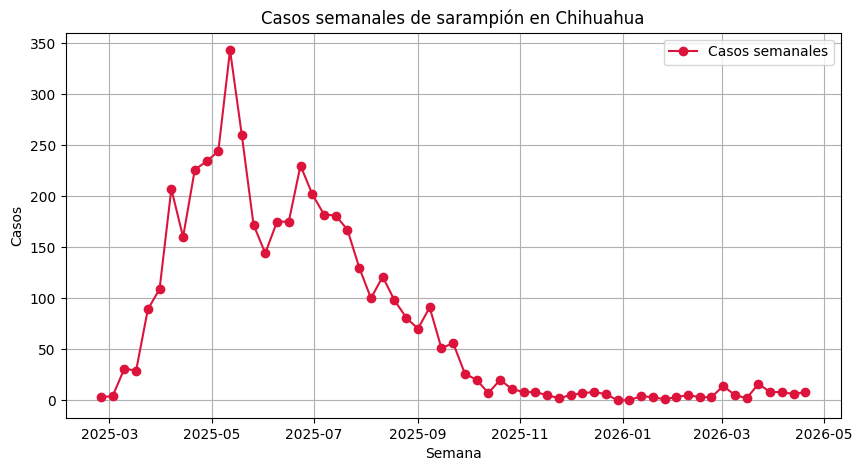

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["SEMANA_DIAG"],
    df["casos_semana"],
    marker="o",
    label="Casos semanales",
    color="crimson"
)

plt.xlabel("Semana")
plt.ylabel("Casos")
plt.title("Casos semanales de sarampión en Chihuahua")
plt.legend()
plt.grid()

plt.show()

### Interpretación
1. ¿En qué semanas aumentan más rápido los casos?
2. ¿Cuándo ocurre el pico?
3. ¿La curva sube y baja de forma simétrica?
4. ¿Hay una cola larga después del pico?
5. ¿Qué nos dice esto sobre la dinámica del brote?

## Casos acumulados

Ahora calculamos:

$$
A_t = \sum_{j=0}^{t} C_j.
$$

In [15]:
df["casos_acumulados"] = df["casos_semana"].cumsum()

df[["SEMANA_DIAG", "casos_semana", "casos_acumulados"]].head()

,SEMANA_DIAG,casos_semana,casos_acumulados
0,2025-02-24,3,3
1,2025-03-03,4,7
2,2025-03-10,31,38
3,2025-03-17,29,67
4,2025-03-24,89,156


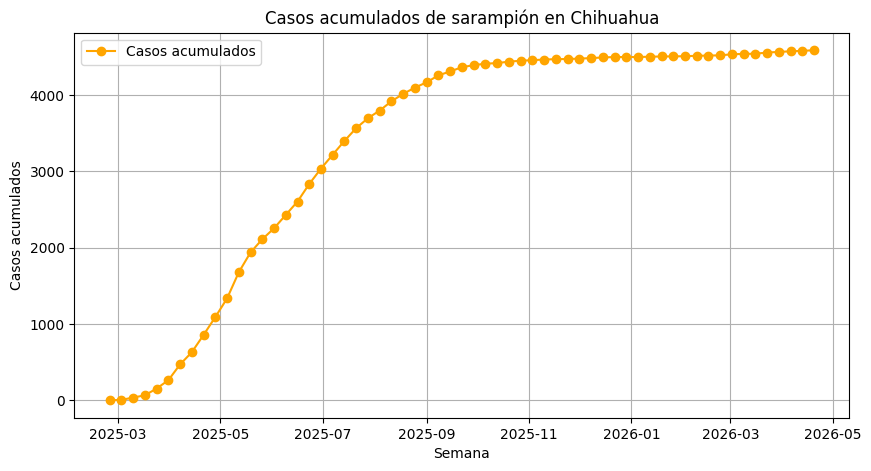

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["SEMANA_DIAG"],
    df["casos_acumulados"],
    marker="o",
    label="Casos acumulados",
    color="orange"
)

plt.xlabel("Semana")
plt.ylabel("Casos acumulados")
plt.title("Casos acumulados de sarampión en Chihuahua")
plt.legend()
plt.grid()

plt.show()

## Interpretación

* Si la pendiente es grande, hay muchas semanas con casos altos.
* Si la pendiente se reduce, el brote está perdiendo intensidad.
* Si se estabiliza, aparecen pocos casos nuevos.

## Cambio semanal de casos

Calculamos el cambio absoluto:

$$
\Delta C_t = C_t - C_{t-1}.
$$

In [17]:
df["cambio_semanal"] = df["casos_semana"].diff()

df[["SEMANA_DIAG", "casos_semana", "cambio_semanal"]].head(10)

,SEMANA_DIAG,casos_semana,cambio_semanal
0,2025-02-24,3,NaN
1,2025-03-03,4,1.0
2,2025-03-10,31,27.0
3,2025-03-17,29,-2.0
4,2025-03-24,89,60.0
5,2025-03-31,109,20.0
6,2025-04-07,207,98.0
7,2025-04-14,160,-47.0
8,2025-04-21,226,66.0
9,2025-04-28,234,8.0


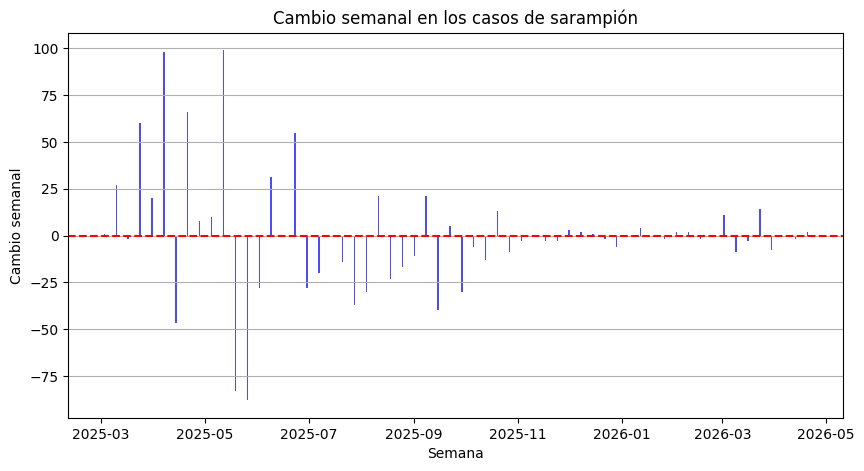

In [18]:
plt.figure(figsize=(10, 5))

plt.axhline(y=0, linestyle="--",color='red')
plt.bar(df["SEMANA_DIAG"], df["cambio_semanal"], color='blue',alpha=0.7)

plt.xlabel("Semana")
plt.ylabel("Cambio semanal")
plt.title("Cambio semanal en los casos de sarampión")
plt.grid(axis="y")

plt.show()

### Interpretación

El cambio semanal permite ver si los casos están aumentando o disminuyendo.

* Valores positivos: los casos aumentaron respecto a la semana anterior.
* Valores negativos: los casos disminuyeron.
* Valores cercanos a cero: estabilidad relativa.

# Promedio móvil

El promedio móvil suaviza la serie y ayuda a ver la tendencia.

Para una ventana de 3 semanas:

$$
MA_t = \frac{C_t + C_{t-1} + C_{t-2}}{3}.
$$


In [19]:
df["promedio_movil_3"] = df["casos_semana"].rolling(window=3).mean()
df["promedio_movil_5"] = df["casos_semana"].rolling(window=5).mean()

df[["SEMANA_DIAG", "casos_semana", "promedio_movil_3", "promedio_movil_5"]].head(10)

,SEMANA_DIAG,casos_semana,promedio_movil_3,promedio_movil_5
0,2025-02-24,3,NaN,NaN
1,2025-03-03,4,NaN,NaN
2,2025-03-10,31,12.666667,NaN
3,2025-03-17,29,21.333333,NaN
4,2025-03-24,89,49.666667,31.2
5,2025-03-31,109,75.666667,52.4
6,2025-04-07,207,135.000000,93.0
7,2025-04-14,160,158.666667,118.8
8,2025-04-21,226,197.666667,158.2
9,2025-04-28,234,206.666667,187.2


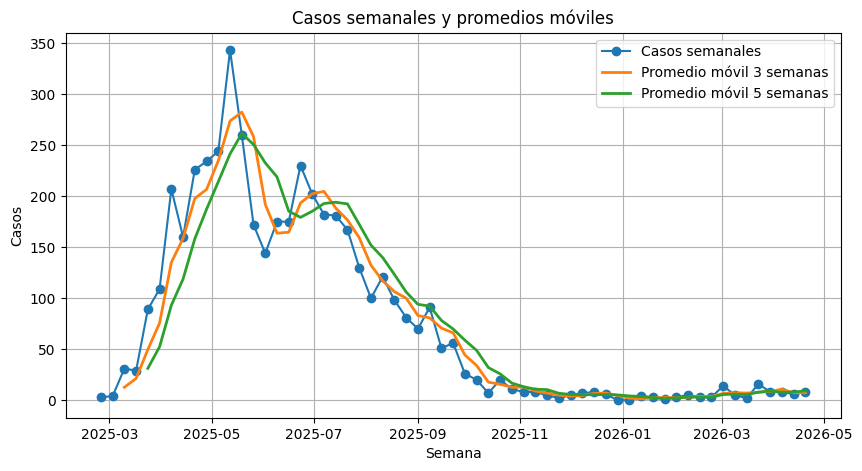

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["SEMANA_DIAG"],
    df["casos_semana"],
    marker="o",
    label="Casos semanales"
)

plt.plot(
    df["SEMANA_DIAG"],
    df["promedio_movil_3"],
    linewidth=2,
    label="Promedio móvil 3 semanas"
)

plt.plot(
    df["SEMANA_DIAG"],
    df["promedio_movil_5"],
    linewidth=2,
    label="Promedio móvil 5 semanas"
)

plt.xlabel("Semana")
plt.ylabel("Casos")
plt.title("Casos semanales y promedios móviles")
plt.legend()
plt.grid()

plt.show()

### Interpretación

El promedio móvil reduce fluctuaciones locales y permite observar mejor la tendencia general. Sin embargo, también puede ocultar cambios bruscos importantes.

## Rezagos temporales

Un rezago permite comparar los casos actuales con los de semanas anteriores.

$$
C_{t-1}, \quad C_{t-2}, \quad C_{t-3}.
$$

In [21]:
df["lag_1"] = df["casos_semana"].shift(1)
df["lag_2"] = df["casos_semana"].shift(2)
df["lag_3"] = df["casos_semana"].shift(3)

df[["SEMANA_DIAG", "casos_semana", "lag_1", "lag_2", "lag_3"]].head(10)

,SEMANA_DIAG,casos_semana,lag_1,lag_2,lag_3
0,2025-02-24,3,NaN,NaN,NaN
1,2025-03-03,4,3.0,NaN,NaN
2,2025-03-10,31,4.0,3.0,NaN
3,2025-03-17,29,31.0,4.0,3.0
4,2025-03-24,89,29.0,31.0,4.0
5,2025-03-31,109,89.0,29.0,31.0
6,2025-04-07,207,109.0,89.0,29.0
7,2025-04-14,160,207.0,109.0,89.0
8,2025-04-21,226,160.0,207.0,109.0
9,2025-04-28,234,226.0,160.0,207.0


Los rezagos son importantes porque muchos modelos predictivos usan el pasado para predecir el presente o el futuro.

Por ejemplo:

$$
C_t \approx f(C_{t-1}, C_{t-2}, C_{t-3}).
$$

# Variable objetivo para predicción

Podemos construir una variable de casos de la siguiente semana:

$$
C_{t+1}.
$$

In [22]:
df["casos_siguiente_semana"] = df["casos_semana"].shift(-1)

df_modelo = df[[
    "SEMANA_DIAG",
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "promedio_movil_3",
    "casos_siguiente_semana"
]].copy()

df_modelo.head(10)

,SEMANA_DIAG,casos_semana,lag_1,lag_2,lag_3,promedio_movil_3,casos_siguiente_semana
0,2025-02-24,3,NaN,NaN,NaN,NaN,4.0
1,2025-03-03,4,3.0,NaN,NaN,NaN,31.0
2,2025-03-10,31,4.0,3.0,NaN,12.666667,29.0
3,2025-03-17,29,31.0,4.0,3.0,21.333333,89.0
4,2025-03-24,89,29.0,31.0,4.0,49.666667,109.0
5,2025-03-31,109,89.0,29.0,31.0,75.666667,207.0
6,2025-04-07,207,109.0,89.0,29.0,135.000000,160.0
7,2025-04-14,160,207.0,109.0,89.0,158.666667,226.0
8,2025-04-21,226,160.0,207.0,109.0,197.666667,234.0
9,2025-04-28,234,226.0,160.0,207.0,206.666667,244.0


Eliminamos filas incompletas:

In [23]:
df_modelo = df_modelo.dropna()

df_modelo.head()

,SEMANA_DIAG,casos_semana,lag_1,lag_2,lag_3,promedio_movil_3,casos_siguiente_semana
3,2025-03-17,29,31.0,4.0,3.0,21.333333,89.0
4,2025-03-24,89,29.0,31.0,4.0,49.666667,109.0
5,2025-03-31,109,89.0,29.0,31.0,75.666667,207.0
6,2025-04-07,207,109.0,89.0,29.0,135.000000,160.0
7,2025-04-14,160,207.0,109.0,89.0,158.666667,226.0


## Interpretación de la tabla preparada

Esta tabla ya tiene estructura para un modelo predictivo sencillo.

Podríamos usar como variables predictoras:

$$
X = {C_t, C_{t-1}, C_{t-2}, C_{t-3}, MA_3}
$$

y como variable objetivo:

$$
y = C_{t+1}.
$$

In [24]:
X = df_modelo[["casos_semana", "lag_1", "lag_2", "lag_3", "promedio_movil_3"]]

y = df_modelo["casos_siguiente_semana"]

print(X.head())
print(y.head())

   casos_semana  lag_1  lag_2  lag_3  promedio_movil_3
3            29   31.0    4.0    3.0         21.333333
4            89   29.0   31.0    4.0         49.666667
5           109   89.0   29.0   31.0         75.666667
6           207  109.0   89.0   29.0        135.000000
7           160  207.0  109.0   89.0        158.666667
3     89.0
4    109.0
5    207.0
6    160.0
7    226.0
Name: casos_siguiente_semana, dtype: float64


En la siguiente clase, esta estructura nos permitirá construir un primer modelo predictivo simple.

## Análisis por municipio

Ahora analizamos qué municipios concentran más casos acumulados.

In [25]:
casos_municipio = df[cols_municipios].sum().sort_values(ascending=False)

print(casos_municipio.head(10))

CUAUHTÉMOC             1448
CHIHUAHUA               867
NUEVO CASAS GRANDES     208
GUACHOCHI               192
OJINAGA                 184
JUÁREZ                  181
DELICIAS                163
CAMARGO                 143
AHUMADA                 114
GUERRERO                105
dtype: int64


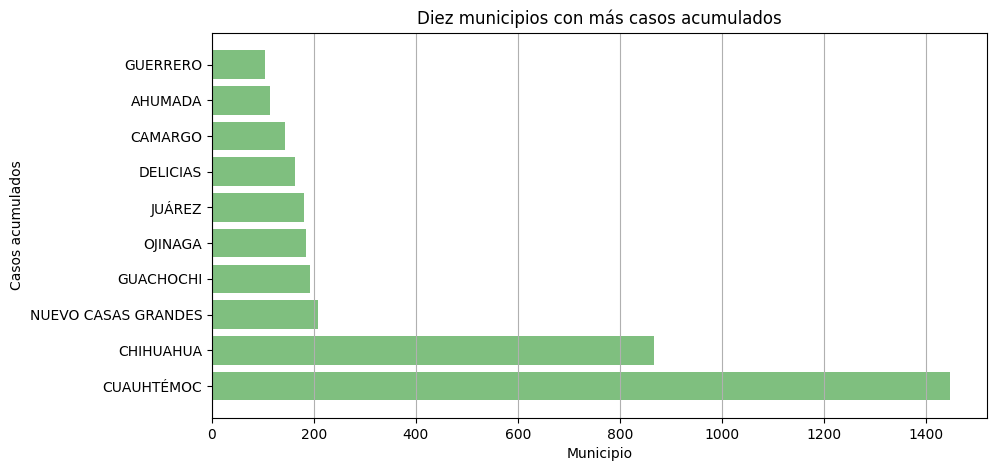

In [26]:
top10 = casos_municipio.head(10)

plt.figure(figsize=(10, 5))

plt.barh(top10.index, top10.values, color='green',alpha=0.5)

plt.xlabel("Municipio")
plt.ylabel("Casos acumulados")
plt.title("Diez municipios con más casos acumulados")
plt.grid(axis="x")

plt.show()

## Interpretación

1. ¿El brote se concentra en pocos municipios?
2. ¿Hay mucha diferencia entre el municipio con más casos y los demás?
3. ¿Qué información adicional necesitaríamos para comparar mejor municipios?

Es mejor comparar tasas y no solo conteos, porque los municipios tienen poblaciones distintas.

Cálculo epidemiológico estándar para tasas poblacionales

$$\text{Tasa de Incidencia} = \left( \frac{\text{CASOS}}{\text{POB\_TOT}} \right) \times 100,000$$

Esto estandariza el riesgo sin importar el tamaño absoluto del municipio, permitiendo comparar municipios pequeños y densamente poblados en la misma escala.

In [27]:
ruta_pob = 'https://raw.githubusercontent.com/jamc88/Taller-Modelado-I/refs/heads/main/Datos/poblacion_municipios_chihuahua_2020.csv'
municipios_poblacion = pd.read_csv(ruta_pob)
municipios_poblacion

,NOM_MUN,POB_TOT
0,JUÁREZ,1512450
1,CHIHUAHUA,937674
2,CUAUHTÉMOC,180638
3,DELICIAS,150506
4,HIDALGO DEL PARRAL,116662
...,...,...
62,EL TULE,1448
63,MAGUARICHI,1302
64,COYAME DEL SOTOL,1230
65,MANUEL BENAVIDES,1178


In [28]:
df_casos = casos_municipio.reset_index()
df_casos.columns = ['NOM_MUN', 'CASOS']
df_casos.head()

,NOM_MUN,CASOS
0,CUAUHTÉMOC,1448
1,CHIHUAHUA,867
2,NUEVO CASAS GRANDES,208
3,GUACHOCHI,192
4,OJINAGA,184


Hacemos el cruce (Left join) manteniendo todos los municipios

In [29]:
df_completo = pd.merge(
    municipios_poblacion,
    df_casos,
    on='NOM_MUN',
    how='left'
)

In [30]:
df_completo

,NOM_MUN,POB_TOT,CASOS
0,JUÁREZ,1512450,181.0
1,CHIHUAHUA,937674,867.0
2,CUAUHTÉMOC,180638,1448.0
3,DELICIAS,150506,163.0
4,HIDALGO DEL PARRAL,116662,15.0
...,...,...,...
62,EL TULE,1448,NaN
63,MAGUARICHI,1302,NaN
64,COYAME DEL SOTOL,1230,NaN
65,MANUEL BENAVIDES,1178,NaN


Llenamos los valores nulos (municipios que no reportaron casos) con 0

In [31]:
df_completo['CASOS'] = df_completo['CASOS'].fillna(0).astype(int)

In [32]:
df_completo

,NOM_MUN,POB_TOT,CASOS
0,JUÁREZ,1512450,181
1,CHIHUAHUA,937674,867
2,CUAUHTÉMOC,180638,1448
3,DELICIAS,150506,163
4,HIDALGO DEL PARRAL,116662,15
...,...,...,...
62,EL TULE,1448,0
63,MAGUARICHI,1302,0
64,COYAME DEL SOTOL,1230,0
65,MANUEL BENAVIDES,1178,0


 Calculamos la tasa de incidencia (casos por cada 100,000 habitantes)

In [33]:
df_completo['TASA_100K'] = (df_completo['CASOS'] / df_completo['POB_TOT']) * 100000

In [34]:
df_completo.head()

,NOM_MUN,POB_TOT,CASOS,TASA_100K
0,JUÁREZ,1512450,181,11.967338
1,CHIHUAHUA,937674,867,92.462839
2,CUAUHTÉMOC,180638,1448,801.603206
3,DELICIAS,150506,163,108.301330
4,HIDALGO DEL PARRAL,116662,15,12.857657


In [35]:
top10 = df_completo.sort_values(by='TASA_100K', ascending=False).head(10)
top10

,NOM_MUN,POB_TOT,CASOS,TASA_100K
32,CARICHÍ,8113,86,1060.027117
56,SAN FRANCISCO DE CONCHOS,2696,28,1038.575668
2,CUAUHTÉMOC,180638,1448,801.603206
33,RIVA PALACIO,7695,61,792.722547
24,AHUMADA,14635,114,778.954561
17,OJINAGA,24534,184,749.979620
39,BACHÍNIVA,5807,40,688.823833
43,CUSIHUIRIACHI,5099,30,588.350657
20,NAMIQUIPA,22712,94,413.878126
7,GUACHOCHI,50180,192,382.622559


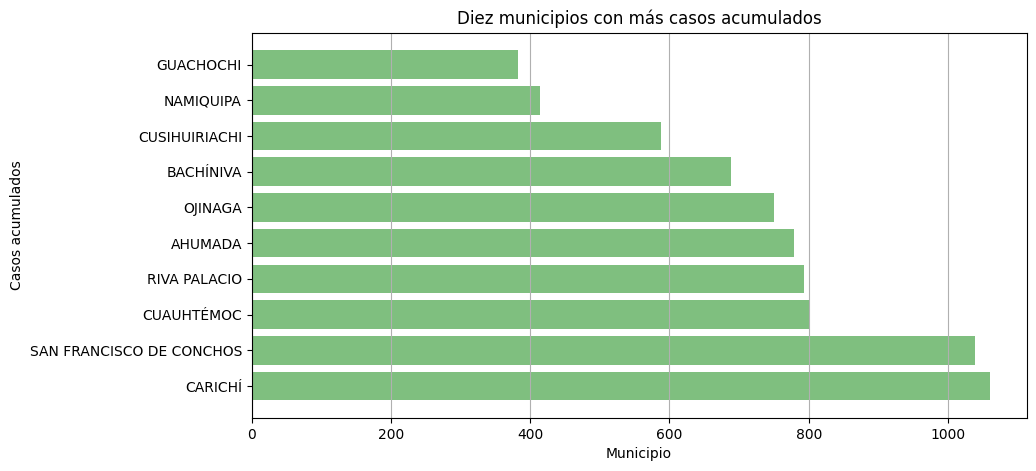

In [36]:
plt.figure(figsize=(10, 5))

plt.barh(top10['NOM_MUN'], top10['TASA_100K'], color='green',alpha=0.5)

plt.xlabel("Municipio")
plt.ylabel("Casos acumulados")
plt.title("Diez municipios con más casos acumulados")
plt.grid(axis="x")

plt.show()

### Porcentaje de contribución municipal

$$
\text{Porcentaje municipal}=
\frac{\text{CASOS del municipio}}{\text{CASOS totales del estado}}\times 100.
$$

In [37]:
df_completo["PORCENTAJE_CASOS"] = (
    100 * df_completo["CASOS"] / df_completo["CASOS"].sum()
)

df_completo.head()

,NOM_MUN,POB_TOT,CASOS,TASA_100K,PORCENTAJE_CASOS
0,JUÁREZ,1512450,181,11.967338,3.945934
1,CHIHUAHUA,937674,867,92.462839,18.901243
2,CUAUHTÉMOC,180638,1448,801.603206,31.567473
3,DELICIAS,150506,163,108.301330,3.553521
4,HIDALGO DEL PARRAL,116662,15,12.857657,0.327011


Ordenamos los municipios que más contribuyen al total de casos:

In [38]:
df_contribucion = df_completo.sort_values(
    by="PORCENTAJE_CASOS",
    ascending=False
)

df_contribucion.head(10)

,NOM_MUN,POB_TOT,CASOS,TASA_100K,PORCENTAJE_CASOS
2,CUAUHTÉMOC,180638,1448,801.603206,31.567473
1,CHIHUAHUA,937674,867,92.462839,18.901243
5,NUEVO CASAS GRANDES,65753,208,316.335376,4.534554
7,GUACHOCHI,50180,192,382.622559,4.185742
17,OJINAGA,24534,184,749.979620,4.011336
0,JUÁREZ,1512450,181,11.967338,3.945934
3,DELICIAS,150506,163,108.301330,3.553521
8,CAMARGO,49499,143,288.894725,3.117506
24,AHUMADA,14635,114,778.954561,2.485284
11,GUERRERO,35473,105,295.999774,2.289078


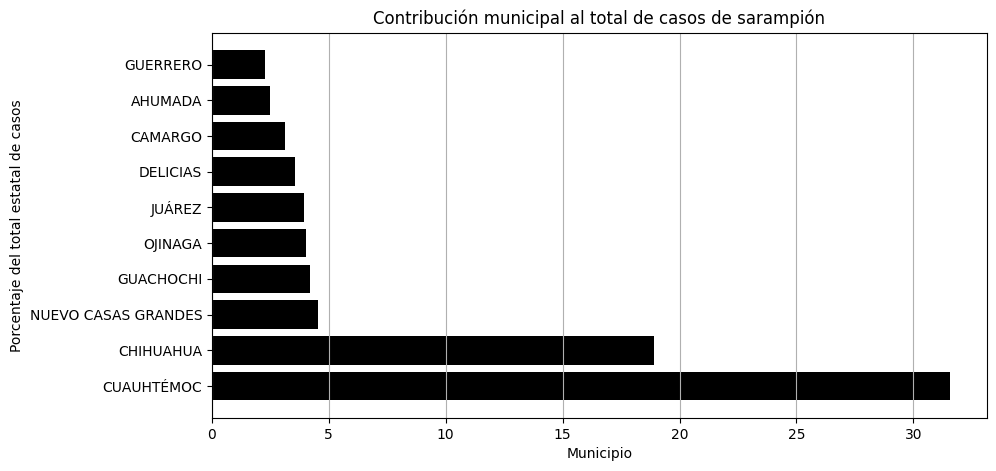

In [39]:
top10 = df_contribucion.head(10)

plt.figure(figsize=(10, 5))

plt.barh(top10["NOM_MUN"], top10["PORCENTAJE_CASOS"], color='black')

plt.xlabel("Municipio")
plt.ylabel("Porcentaje del total estatal de casos")
plt.title("Contribución municipal al total de casos de sarampión")
plt.grid(axis="x")

plt.show()

Antes de construir un modelo predictivo, necesitamos convertir los datos crudos en información útil. La limpieza, la visualización, los promedios móviles y los rezagos son pasos básicos para transformar una serie temporal en una base lista para modelar.